# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}

In [8]:
data =  Elias27

In [9]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 300

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

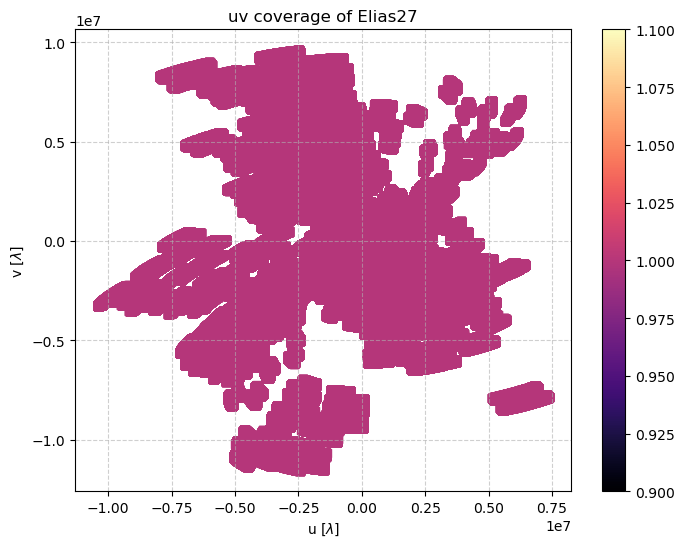

In [10]:
# plot 3D of the uv coverage
plt.figure(figsize=(8, 6))
scatter = plt.scatter(u, v, c= np.ones_like(Vis), cmap='magma', marker=',')
plt.colorbar(scatter)

plt.xlabel(r'u [$\lambda$]')
plt.ylabel(r'v [$\lambda$]')
plt.title('uv coverage of Elias27')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [11]:
import numpy as np
from scipy.special import j0, j1, jn

def synthetic_uvtable_asymmetric(u, v,
                                    sigma_core=0.04,
                                    R_rings=[0.4, 0.6, 0.8],
                                    width_rings=[0.05, 0.02, 0.05],
                                    amp_core=0.1,
                                    amp_rings=[0.05, 0.04, 0.03],
                                    m_modes=[1, 0, 0],        # orden de asimetría por anillo
                                    theta0=[np.pi, 0, 0],  # ángulo central de cada asimetría
                                    amp_asym=[0.5, 0.3, 0.3],        # fuerza relativa de asimetría
                                    rad_to_arcsec=206265.0,
                                    weights=None):
    """
    Generate synthetic uvtable with asymmetric Gaussian-width rings (Fourier-domain model).
    Asymmetry is represented as a low-order azimuthal modulation (m-th mode).
    """
    baseline = np.sqrt(u**2 + v**2)
    phi_uv = np.arctan2(v, u)  # ángulo en el plano uv
    
    # --- Core (centrally symmetric Gaussian) ---
    V_core = amp_core * np.exp(-2 * (np.pi * (sigma_core / rad_to_arcsec) * baseline)**2)
    
    # --- Rings with azimuthal asymmetry ---
    V_rings = np.zeros_like(baseline, dtype=complex)
    
    for A, R, w, m, th0, Aasym in zip(amp_rings, R_rings, width_rings, m_modes, theta0, amp_asym):
        arg = 2 * np.pi * (R / rad_to_arcsec) * baseline
        blur = np.exp(-2 * (np.pi * (w / rad_to_arcsec) * baseline)**2)
        
        # componente axisimétrica (m=0)
        V0 = A * j0(arg) * blur
        
        # componente asimétrica (modo m)
        Vm = Aasym * A * jn(m, arg) * blur * np.exp(1j * m * (phi_uv - th0))
        
        V_rings += V0 + Vm
    
    # --- Combine core + rings ---
    V_total = V_core + V_rings
    Vis = V_total  # complejo
    
    if weights is None:
        weights = np.ones_like(u)
    
    uvtable = {
        'u': u,
        'v': v,
        'vis': Vis,
        'weights': weights
    }
    
    return uvtable

### Creating simulated disc

In [12]:
u, v = uvtable['u'], uvtable['v']

In [13]:
uvtable_synthetic = synthetic_uvtable_asymmetric(u, v, weights=uvtable['weights'])

In [14]:
uvtable_synthetic

{'u': array([-118515.9,  274841.5,  724012.8, ..., -667151.2, -866987.3,
        -776478.4]),
 'v': array([ 332296.2 ,   42829.46,   51970.91, ..., -888292.3 ,  665151.7 ,
         890404.1 ]),
 'vis': array([0.08760246+3.49528632e-03j, 0.0764291 -6.46418990e-04j,
        0.07150178-2.53294934e-04j, ..., 0.04907318+2.18329753e-04j,
        0.0521179 +7.42687861e-06j, 0.03347854-6.88994809e-04j]),
 'weights': array([757.8114, 696.5752, 664.5733, ..., 650.9571, 499.1475, 509.6931])}

In [15]:
frank2d.process_vis(uvtable_synthetic)

Setting gridded data...


In [16]:
uvtable_synthetic_gridded = frank2d.gridded_data

In [17]:
u_syn = uvtable_synthetic_gridded['u'].reshape(N, N)
v_syn = uvtable_synthetic_gridded['v'].reshape(N, N)
vis_syn = uvtable_synthetic_gridded['vis'].reshape(N, N)
weights_syn = uvtable_synthetic_gridded['weights'].reshape(N, N)

Text(0, 0.5, 'v [λ]')

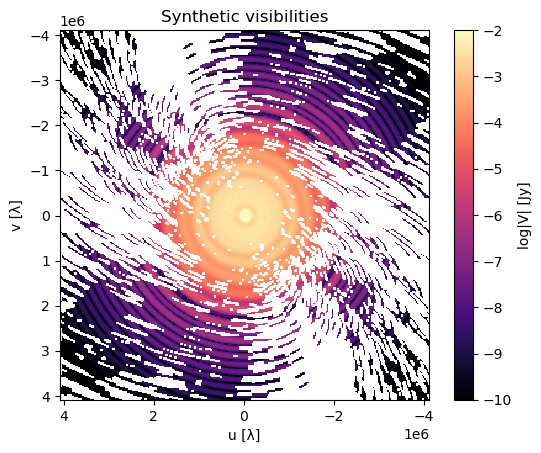

In [18]:
plt.imshow(np.log(np.abs(vis_syn)),
             extent=[u_syn.max(), u_syn.min(), v_syn.max(), v_syn.min()], 
             cmap = "magma", 
             vmin=-10, vmax=-2)
plt.colorbar(label='log|V| [Jy]')
plt.title('Synthetic visibilities')
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')

In [19]:
params_1 = {'m' : -2, 'c' : 1e8, 'l' : 7e4}
params_2 = {'m' : -1.8, 'c' : 1e9, 'l' : 7e4}
params_3 = {'m' : -1.5, 'c' : 1e9, 'l' : 7e4}
best = {'m': -2.421390112312066, 'c': 13585683227.265589, 'l': 166033.03507191344}

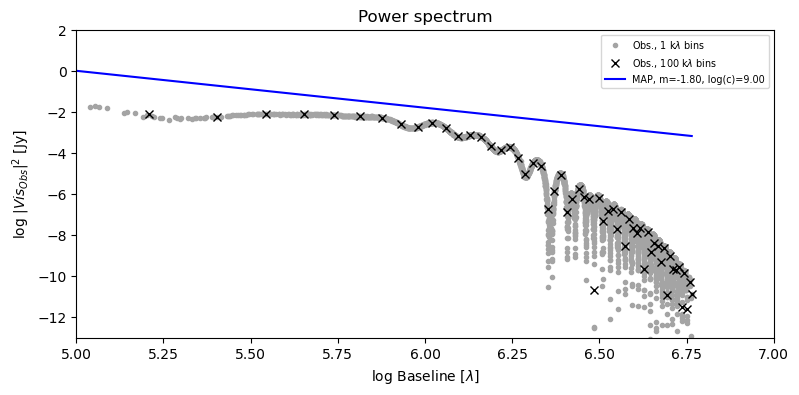

In [20]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = u_syn.flatten(), v_syn.flatten()
Vis = vis_syn.flatten()
Weights = weights_syn.flatten()

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

lgy1 = linear_power_spectrum(lgx, params_1['m'], params_1['c'])
lgy2 = linear_power_spectrum(lgx, params_2['m'], params_2['c'])
lgy3 = linear_power_spectrum(lgx, params_3['m'], params_3['c'])
#lgy_best = linear_power_spectrum(lgx, best['m'], best['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(lgx, lgy1, ls='-', color= 'r', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_1['m'], np.log10(params_1['c'])))
plt.plot(lgx, lgy2, ls='-', color= 'blue', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_2['m'], np.log10(params_2['c'])))
#plt.plot(lgx, lgy3, ls='-', color= 'green', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_3['m'], np.log10(params_3['c'])))
#plt.plot(lgx, lgy_best, ls='--', color= 'orange', label='Best fit, m={:.2f}, log(c)={:.2f}'.format(best['m'], np.log10(best['c'])))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-13, 2)
plt.xlim(5, 7)
plt.show()

In [21]:
dx = frank2d.dx/rad_to_arcsec
dy = frank2d.dy/rad_to_arcsec
I_syn = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_syn))).real/(dx * dy)

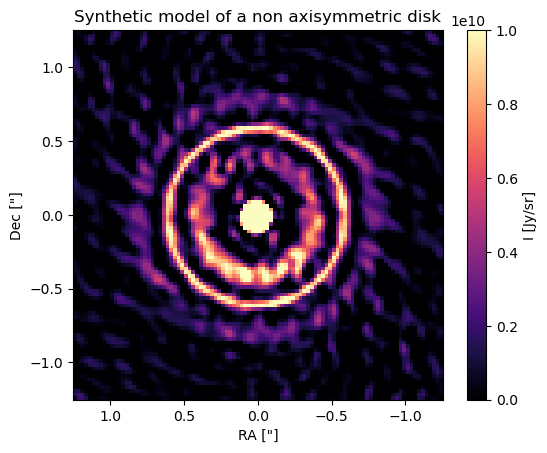

In [22]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1, vmin = 0, vmax = 1e10)

plt.imshow(I_syn, 
            extent=[-frank2d.Rmax, frank2d.Rmax, -frank2d.Rmax, frank2d.Rmax],
            norm=norm, 
            cmap = 'magma'
            )
plt.xlim(rout/3, -rout/3)
plt.ylim(-rout/3, rout/3)
plt.title('Synthetic model of a non axisymmetric disk')
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]')

In [23]:
geom = Geometry(0, 0, 0, 0)

In [24]:
frank2d2 = Frank2D(N, rout, geom)

In [25]:
best = {'m': -2.0109174914721892, 'c': 10930405059.44571, 'l': 2633846.3020098973}


: 

In [26]:
frank2d2.fit(data = uvtable_synthetic, kernel_params = best, rtol = 1e-8)

Setting gridded data...
Setting GP Kernel Wendland...
 + Kernel parameters:  {'m': -2.0109174914721892, 'c': 10930405059.44571, 'l': 2633846.3020098973}
Creating sparse linear system...


In [ ]:
Plot_ = Plot(frank2d2)

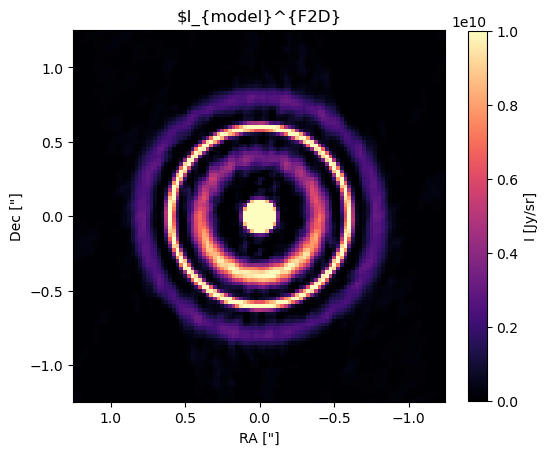

In [ ]:
Plot_.intensity(vmax=1e10, gamma = 1, zoom = 3, title = r'$I_{model}^{F2D}')

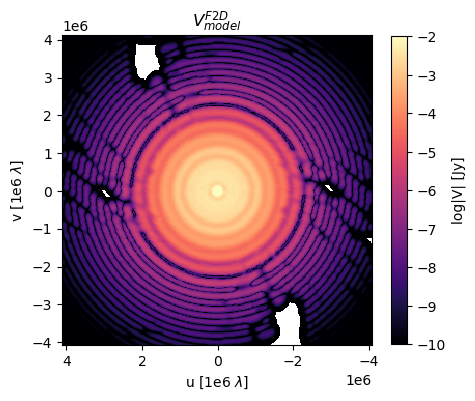

In [ ]:
Plot_.visibility(fig_size=5, title= r'$V_{model}^{F2D}$')

###  Best

In [49]:
initial_guess = {'m': -2, 'logl': 4}

In [50]:
frank2d2.search_MAP(initial_guess= initial_guess)

Using existing visibility data...
Fitting the visibilities with Frank2D with 2DFT...


  + Time to set up the matrices: 59.25 seconds
Setting the initial guess...
Optimizing the posterior...


In [51]:
frank2d2.MAP

{'m': -2.0109174914721892, 'c': 10930405059.44571, 'l': 2633846.3020098973}